In [1]:
sc.install_pypi_package("numpy")
sc.install_pypi_package("pandas")


VBox()

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
2,application_1774012013485_0003,pyspark,idle,Link,Link,None,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.8.1
    Not uninstalling python-dateutil at /usr/lib/python3.9/site-packages, outside environment /mnt/yarn/usercache/livy/appcache/application_1774012013485_0003/container_1774012013485_0003_01_000001/tmp/spark-12d00724-a14f-430e-8354-7f89fc2a16a0
    Can't uninstall 'python-dateutil'. No files were found to uninstall.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.3.3 requires tzdata>=2022.7, which is not installed.
matplotlib 3.9.4 requires contourpy>=1.0.1, which is not installed.
matplotlib 3.9.4 requires cycler>=0.10, which is not installed.
matplotlib 3.9.4 requires fonttools>=4.22.0, which is not installed.
matplotlib 3.9.4 requires importlib-resources>=3.2.0; python_version < "3.10", which is not installed.
matplotlib 3.9.4 requires kiwisolver>=1.3.1,

In [2]:
sc.install_pypi_package("matplotlib")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [3]:
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, FloatType
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import pandas as pd

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [4]:
# # read data from s3

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [5]:
S3_INPUT_PATH = "s3://csc555-emr-studiok/Video_Games.jsonl"
raw_df = spark.read.json(S3_INPUT_PATH)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [6]:
print(f"Total rows: {raw_df.count():,}")
raw_df.printSchema()
raw_df.show(5, truncate=True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Total rows: 4,624,615
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)

+----------+------------+------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|      asin|helpful_vote|images|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase|
+---

In [7]:
# Data Cleaning

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [8]:
reviews_df = raw_df.filter(F.col("verified_purchase") == True).select(
    F.col("user_id").alias("user_id_raw"),
    F.col("asin").alias("item_id_raw"),
    F.col("rating").cast(FloatType())
)

# Drop rows with null values 
reviews_df = reviews_df.dropna(subset=["user_id_raw", "item_id_raw", "rating"])

# Filter out invalid ratings
reviews_df = reviews_df.filter((F.col("rating") >= 1) & (F.col("rating") <= 5))

print(f"Rows after cleaning: {reviews_df.count():,}")
reviews_df.describe("rating").show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Rows after cleaning: 3,982,807
+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|           3982807|
|   mean| 4.098450916652502|
| stddev|1.4079250842498143|
|    min|               1.0|
|    max|               5.0|
+-------+------------------+

In [9]:
# Cold start filtering


VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [10]:
MIN_USER_REVIEWS = 5
MIN_ITEM_REVIEWS = 5

user_counts = reviews_df.groupBy("user_id_raw").count().filter(F.col("count") >= MIN_USER_REVIEWS)
item_counts = reviews_df.groupBy("item_id_raw").count().filter(F.col("count") >= MIN_ITEM_REVIEWS)

reviews_df = reviews_df \
    .join(user_counts.select("user_id_raw"), on="user_id_raw", how="inner") \
    .join(item_counts.select("item_id_raw"), on="item_id_raw", how="inner")

print(f"Rows after cold-start filter: {reviews_df.count():,}")
print(f"Unique users: {reviews_df.select('user_id_raw').distinct().count():,}")
print(f"Unique items: {reviews_df.select('item_id_raw').distinct().count():,}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Rows after cold-start filter: 706,564
Unique users: 90,846
Unique items: 59,042

In [11]:
# Encode string IDs to integer indices


VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [12]:
user_indexer = StringIndexer(inputCol="user_id_raw", outputCol="user_id", handleInvalid="skip")
item_indexer = StringIndexer(inputCol="item_id_raw", outputCol="item_id", handleInvalid="skip")

pipeline = Pipeline(stages=[user_indexer, item_indexer])
indexer_model = pipeline.fit(reviews_df)
indexed_df = indexer_model.transform(reviews_df)

# Cast to integer — ALS requires Int, not Double
indexed_df = indexed_df \
    .withColumn("user_id", F.col("user_id").cast(IntegerType())) \
    .withColumn("item_id", F.col("item_id").cast(IntegerType()))

final_df = indexed_df.select("user_id", "item_id", "rating")
# final_df.cache()
final_df.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+-------+------+
|user_id|item_id|rating|
+-------+-------+------+
|  10368|  47616|   5.0|
|  11405|   1608|   4.0|
|  67318|   1608|   5.0|
|  33725|   1608|   5.0|
|  83959|   1608|   5.0|
+-------+-------+------+
only showing top 5 rows

In [13]:
# EDA

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

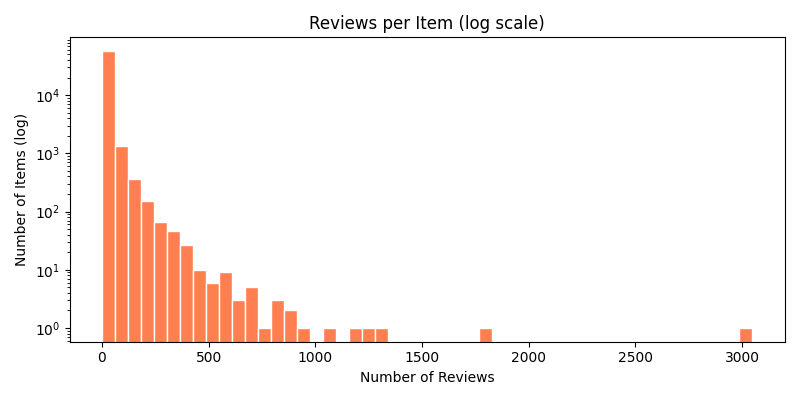

In [14]:
# --- Reviews per Item ---
reviews_per_item = final_df.groupBy("item_id").count().toPandas()

plt.figure(figsize=(8, 4))
plt.hist(reviews_per_item["count"], bins=50, color="coral", edgecolor="white", log=True)
plt.title("Reviews per Item (log scale)")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Items (log)")
plt.tight_layout()
plt.show()
%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

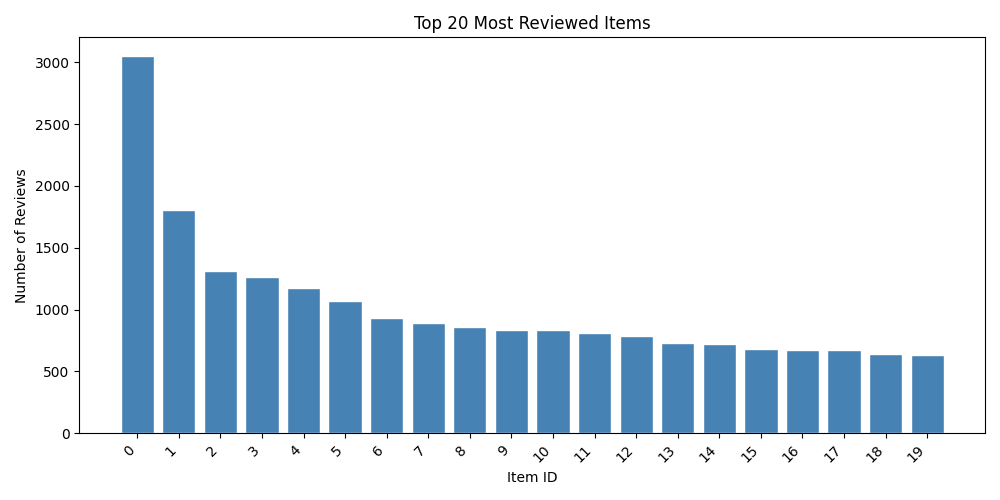

In [15]:
# --- Top 20 Most Reviewed Items ---
top_items = (final_df.groupBy("item_id")
             .count()
             .orderBy(F.desc("count"))
             .limit(20)
             .toPandas())

plt.figure(figsize=(10, 5))
plt.bar(top_items["item_id"].astype(str), top_items["count"], color="steelblue", edgecolor="white")
plt.title("Top 20 Most Reviewed Items")
plt.xlabel("Item ID")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
%matplot plt

In [16]:
# Train & Split data

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [17]:
train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

train_df.cache()
test_df.cache()

print(f"Training rows: {train_df.count():,}")
print(f"Test rows:     {test_df.count():,}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Training rows: 564,729
Test rows:     141,835

In [18]:
# Train ALS Model

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [19]:
als = ALS(
    userCol="user_id",
    itemCol="item_id",
    ratingCol="rating",
    rank=10,                   # Number of latent factors
    maxIter=10,                # Number of ALS iterations
    regParam=0.1,              # Regularization — prevents overfitting
    coldStartStrategy="drop",  # Drop rows with unknown users/items at test time
    nonnegative=True           # Enforce non-negative factors (good for ratings)
)

model = als.fit(train_df)
print("ALS model trained successfully.")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

ALS model trained successfully.

In [20]:
# Evaluate model

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [21]:
predictions = model.transform(test_df)

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(predictions)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

mae_evaluator = RegressionEvaluator(
    metricName="mae",
    labelCol="rating",
    predictionCol="prediction"
)
mae = mae_evaluator.evaluate(predictions)
print(f"Mean Absolute Error (MAE):      {mae:.4f}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Root Mean Squared Error (RMSE): 1.2700
Mean Absolute Error (MAE):      0.9617

In [22]:
# Hyperparameter Tuning (Cross-validation)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [23]:
param_grid = ParamGridBuilder() \
    .addGrid(als.rank, [10,20]) \
    .addGrid(als.regParam, [0.01,0.1]) \
    .build()

cv = CrossValidator(
    estimator=als,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

cv_model = cv.fit(train_df)
best_model = cv_model.bestModel

print(f"Best rank:     {best_model.rank}")
print(f"Best regParam: {best_model._java_obj.parent().getRegParam()}")

best_predictions = best_model.transform(test_df)

best_predictions = best_predictions.withColumn(
    "prediction", F.least(F.lit(5.0), F.greatest(F.lit(1.0), F.col("prediction")))
)
best_rmse = evaluator.evaluate(best_predictions)
print(f"Best model RMSE: {best_rmse:.4f}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Best rank:     20
Best regParam: 0.1
Best model RMSE: 1.2376

In [24]:
# Generate Top-N recommendations

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [25]:
# Top 10 game recommendations for each user
user_recs = best_model.recommendForAllUsers(10)
user_recs.show(5, truncate=False)

# Top 10 user recommendations for each game
item_recs = best_model.recommendForAllItems(10)
item_recs.show(5, truncate=False)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id|recommendations                                                                                                                                                                                       |
+-------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|12     |[{46757, 6.3672395}, {48894, 6.3396645}, {53534, 6.236485}, {20959, 6.18606}, {49135, 6.075948}, {51469, 6.0148664}, {27743, 5.973169}, {23854, 5.973169}, {20856, 5.9024973}, {48977, 5.877282}]     |
|65     |[{48894, 6.410666}, {51469, 6.0603237}, {45719, 6.038645}, {55384, 5.9611864}, {30778, 5.9485703}, {38586, 5.938187}, {50157, 5.813372}, {48427, 5.7991877}

In [26]:
# Example: recommendations for a specific user
sample_user_id = final_df.select("user_id").first()[0]

sample_users = spark.createDataFrame([(sample_user_id,)], ["user_id"])
sample_recs = best_model.recommendForUserSubset(sample_users, 10)

print(f"Top 10 recommendations for user_id={sample_user_id}:")
sample_recs.select("user_id", F.explode("recommendations").alias("rec")) \
    .select("user_id", "rec.item_id", "rec.rating") \
    .show(10)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Top 10 recommendations for user_id=10368:
+-------+-------+---------+
|user_id|item_id|   rating|
+-------+-------+---------+
|  10368|  48894| 7.103205|
|  10368|  53534|6.9203634|
|  10368|  31363|6.8325133|
|  10368|  26310| 6.765393|
|  10368|  45719| 6.682265|
|  10368|   9889| 6.592835|
|  10368|  38586| 6.578359|
|  10368|  40753|6.5702734|
|  10368|  33803|6.5702734|
|  10368|  37937|6.5496645|
+-------+-------+---------+

In [27]:
# Visualization


VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

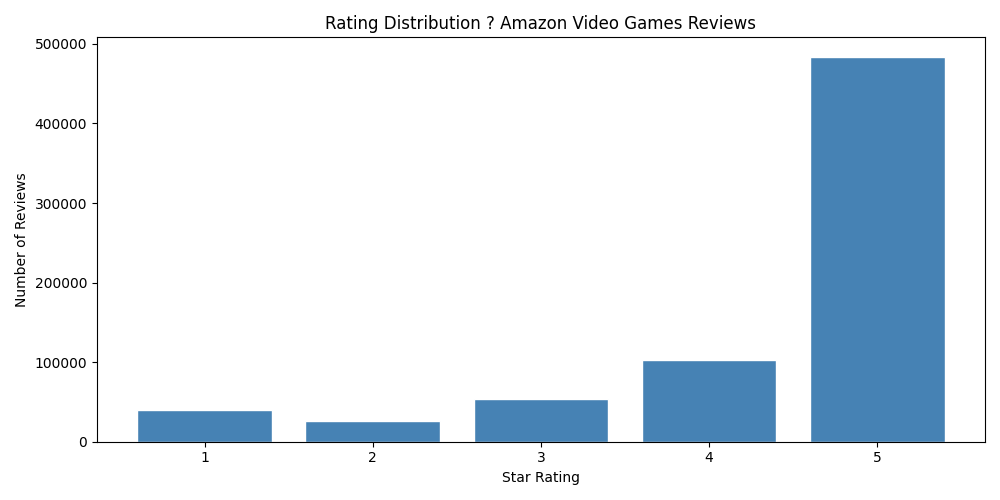

In [28]:
# --- Rating Distribution ---
rating_dist = final_df.groupBy("rating").count().orderBy("rating").toPandas()

plt.figure(figsize=(10, 5))
plt.bar(rating_dist["rating"], rating_dist["count"], color="steelblue", edgecolor="white")
plt.title("Rating Distribution — Amazon Video Games Reviews")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()
%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

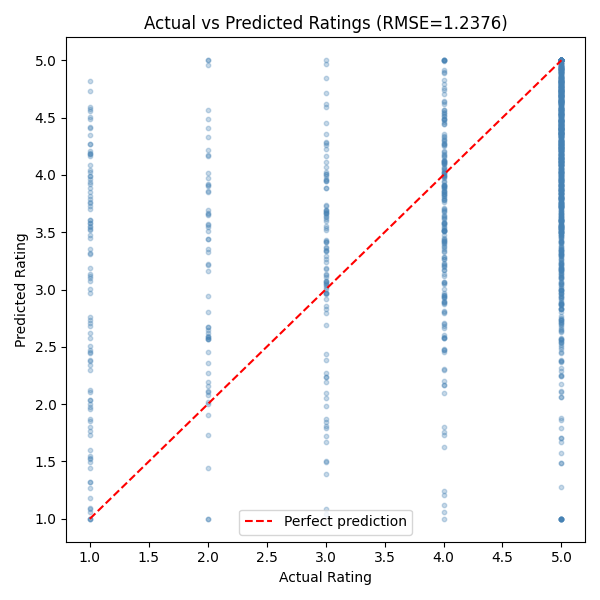

In [29]:
# --- Actual vs Predicted Ratings ---
sample_preds = best_predictions.sample(fraction=0.01, seed=42).toPandas()

plt.figure(figsize=(6, 6))
plt.scatter(sample_preds["rating"], sample_preds["prediction"], alpha=0.3, s=10, color="steelblue")
plt.plot([1, 5], [1, 5], "r--", label="Perfect prediction")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title(f"Actual vs Predicted Ratings (RMSE={best_rmse:.4f})")
plt.legend()
plt.tight_layout()
plt.show()
%matplot plt


VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

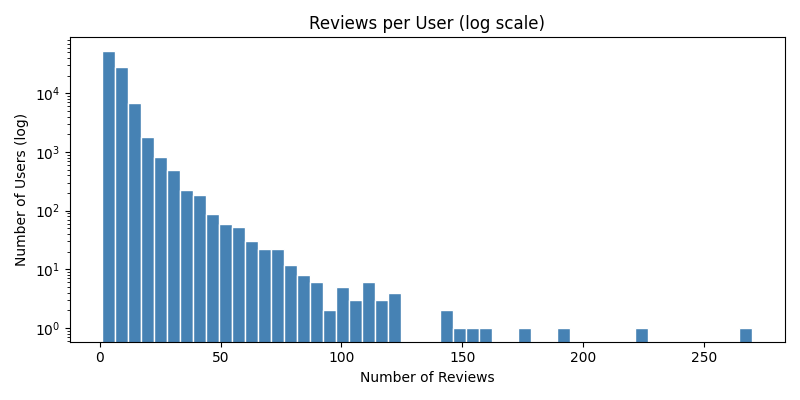

In [30]:
# --- Reviews per User Distribution ---
reviews_per_user = final_df.groupBy("user_id").count().toPandas()

plt.figure(figsize=(8, 4))
plt.hist(reviews_per_user["count"], bins=50, color="steelblue", edgecolor="white", log=True)
plt.title("Reviews per User (log scale)")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Users (log)")
plt.tight_layout()
plt.show()
%matplot plt

In [31]:
S3_OUTPUT_PATH = "s3://csc555-emr-studiok/output/"

# Save top recommendations
user_recs.write.mode("overwrite").parquet(S3_OUTPUT_PATH + "user_recommendations/")

# Save predictions
best_predictions.write.mode("overwrite").parquet(S3_OUTPUT_PATH + "test_predictions/")

print(f"Results written to {S3_OUTPUT_PATH}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Results written to s3://csc555-emr-studiok/output/